<a href="https://colab.research.google.com/github/MaggieKinsella/FinalProject/blob/main/Behavioral_Health_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: Exploring Data for Impact: An EDA and Visualization Project**

# **National Substance Use and Mental Health Services**

By: Maggie Kinsella & Melissa Bernal Garcia

## **1. Introduction to the Data Set and  Variables**

Substance abuse in the U.S. not only harms individuals who misuse substances but also contributes to the decline of our healthcare, education, and social systems. Over the years, both substance abuse and mental health disorders have increasingly become more and more prevelant. As a result, the demand for national support services and resources has grown.

For this Exploratory Data Analysis and Visualization project, we will analyze data collected by SAMHSA on substance use and health services offered by treatment facilities across the United States from 2020 to 2024. The N-SUMHSS is a voluntary survey designed to collect data on the location, characteristics, and utilization of organized substance use and mental health treatment services for facilities. Three data collection modes were used; a secure web-based questionnaire, a paper questionnaire sent by mail, and a computer-assisted telephone interview.

### **Data Source**
- **Source:** *SAMHSA* - Substance Abuse and Mental Health Services Administration
- **Dataset:** National Substance Use and Mental Health Services Survey
- **Collection Method:** Survey data


**Variable Decriptions**
- This data set has 1,058 columns (variables) and 132,726 rows (entries).
- This data consists of nominal and categorical variables representing two possible outcomes (yes or no)

## **2. Project Goals**

The goal of our project is to investigate mental health and subtstance abuse in the U.S. by analyzing the distribution of specialized services

Reasearch questions
1. Are behavior health facilities evenly distributed across the U.S. relative to population size?
2. What types of services are most and least commonly offered?
3. Is there a relationship between facility type and services offered?
4. What disparities exist in access to behavioral health services?
5. How does financial accessibility affect different age groups and demographics?
6. How do payment options vary across different behavioral health services?

## **3. Data Cleaning and Preprocessing**

In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import data set
df_2024 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSUMHSS_2024_PUF_CSV.csv')
df_2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSUMHSS_2023_PUF_CSV.csv')
df_2022 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSUMHSS_2022_PUF_CSV.csv')
df_2021 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSUMHSS_2021_PUF_CSV.csv')
df_2020 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nmhss-puf-2020-csv.csv')

In [ ]:
df_2024['YEAR'] = 2024
df_2023['YEAR'] = 2023
df_2022['YEAR'] = 2022
df_2021['YEAR'] = 2021
df_2020['YEAR'] = 2020

In [ ]:
# combine data frames from 2020 - 2024 into a single data frame
df_original = pd.concat([df_2024, df_2023, df_2022, df_2021, df_2020], ignore_index=True)
df_original.head()

,MPRID,INSU,INMH,LOCATIONSTATE,FOCUS,SUTRTMNTALSO,JAIL,OTHNONTX,DETOX,TREATMT_SU,...,LICENMH,LICENSED,LICENPH,LICENHOS,JCAHO,CARF,COA,OTHSTATE,COD_PCT,TOTADMIS
0,100002G,1,1,IN,3,L,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100101S,1,1,TN,3,L,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100120A,M,1,MN,2,0,0,L,L,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100121B,M,1,NJ,2,0,0,L,L,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100176Z,M,1,MI,M,M,M,M,M,M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df_original.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132726 entries, 0 to 132725
Columns: 1058 entries, MPRID to TOTADMIS
dtypes: float64(70), int64(1), object(987)
memory usage: 1.0+ GB


In [ ]:
# check for missing values
df.isnull().sum()

,0
MPRID,44646
INSU,12275
INMH,12275
LOCATIONSTATE,12275
FOCUS,0
...,...
CARF,120451
COA,120451
OTHSTATE,120451
COD_PCT,120451


In [ ]:
# only keep select variables
         # geography
df = df[['LOCATIONSTATE',
         # facility type/info
         'INSU', 'FOCUS',
         # substance use services
         'DETOX', 'TREATMT_SU',
         # mental health services
         'SMISEDSUD_SU',
         # aftercare
         'SRVC37', 'SRVC97', 'SRVC102', 'SRVC39', 'SRVC38',
         # demographic
         'FEMALESRV', 'MALESRV', 'SRVC30', 'SRVC120', 'SRVC63_SU', 'SRVC62_SU', 'SRVC113_SU', 'SRVC114_SU',
         # accessibility
         'REVCHK3', 'REVCHK1_SU', 'REVCHK5_SU', 'REVCHK2_SU']]

In [ ]:
# rename variables in data
df = df.rename(columns={
    'LOCATIONSTATE': 'state',
    'INSU': 'substance_use_facility',
    'FOCUS': 'primary_treatment_focus',
    'DETOX': 'detox_services',
    'TREATMT_SU': 'substance_treatment',
    'SMISEDSUD_SU': 'mental_illness_services',
    'SRVC37': 'discharge_plan',
    'SRVC97': 'recovery_peer_support',
    'SRVC102': 'self_help_groups',
    'SRVC39': 'housing_assist',
    'SRVC38': 'recovery_employment',
    'FEMALESRV': 'female_services',
    'MALESRV': 'male_services',
    'SRVC30': 'serves_adolescents',
    'SRVC120': 'serves_young_adults',
    'SRVC63_SU': 'serves_seniors_adults',
    'SRVC62_SU': 'serves_lgbtq',
    'SRVC113_SU': 'serves_veterans',
    'SRVC114_SU': 'serves_active_duty_military',
    'REVCHK3': 'free_treatment',
    'REVCHK1_SU': 'self_payment',
    'REVCHK5_SU': 'accepts_medicaid',
    'REVCHK2_SU': 'accepts_private_health_insurance'})


df.head()

,state,substance_use_facility,primary_treatment_focus,detox_services,substance_treatment,mental_illness_services,discharge_plan,recovery_peer_support,self_help_groups,housing_assist,...,serves_adolescents,serves_young_adults,serves_seniors_adults,serves_lgbtq,serves_veterans,serves_active_duty_military,free_treatment,self_payment,accepts_medicaid,accepts_private_health_insurance
0,IN,1,3,0,1,1,1,1,1,1,...,0,0,0,NaN,0,0,0,1,1,1
1,TN,1,3,0,1,1,1,1,0,1,...,0,0,0,NaN,0,0,0,1,1,1
2,MN,M,2,L,L,L,L,L,L,L,...,L,L,L,NaN,L,L,L,L,L,L
3,NJ,M,2,L,L,L,L,L,L,L,...,L,L,L,NaN,L,L,L,L,L,L
4,MI,M,M,M,M,M,M,M,M,M,...,M,M,M,NaN,M,M,M,M,M,M


In [ ]:
# replace Missing (M) and Logical Skip (L) with NaN
# create list of columns to convert, everything excecpt state
convert_cols = [col for col in df.columns if col != 'state']

# replace 'M' and 'L' with NaN (so pandas can calculate them)
df[convert_cols] = df[convert_cols].replace(['M', 'L'], np.nan)

# convert values to numeric
for col in convert_cols:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [ ]:
# convert dtype to int8
# still supports calculations and percentages but takes less data when running
# all except 'state'
binary_cols = df.columns[1:]
df[binary_cols] = df[binary_cols].astype('Int8')

## **4. Exploratory Data Analysis (EDA)**

In [ ]:
# list most important columns in data
core_columns = [
    'state',
    'primary_treatment_focus',
    'substance_treatment',
    'mental_illness_services',
    'detox_services',
    'recovery_peer_support',
    'serves_adolescents',
    'serves_seniors_adults'
]

# only keeps row if atleast 6 of these columns are not missing values
df1 = df.dropna(subset = core_columns, thresh = 6)
df1.head()

,state,substance_use_facility,primary_treatment_focus,detox_services,substance_treatment,mental_illness_services,discharge_plan,recovery_peer_support,self_help_groups,housing_assist,...,serves_adolescents,serves_young_adults,serves_seniors_adults,serves_lgbtq,serves_veterans,serves_active_duty_military,free_treatment,self_payment,accepts_medicaid,accepts_private_health_insurance
0,IN,1,3,0,1,1,1,1,1,1,...,0,0,0,<NA>,0,0,0,1,1,1
1,TN,1,3,0,1,1,1,1,0,1,...,0,0,0,<NA>,0,0,0,1,1,1
6,IL,1,1,0,1,1,1,1,1,1,...,0,0,0,<NA>,0,0,0,1,1,1
10,SD,1,3,0,1,1,1,0,1,1,...,1,0,0,<NA>,0,0,0,0,1,0
11,CA,1,1,0,1,1,1,1,1,1,...,0,1,1,<NA>,1,1,0,1,1,0


This filtering approach was utilized as a threshold drop in order to retain rows with a sufficient amount of data while minimizing data loss.

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65431 entries, 0 to 120450
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   state                             65431 non-null  object
 1   substance_use_facility            60015 non-null  Int8  
 2   primary_treatment_focus           65431 non-null  Int8  
 3   detox_services                    65430 non-null  Int8  
 4   substance_treatment               65431 non-null  Int8  
 5   mental_illness_services           65419 non-null  Int8  
 6   discharge_plan                    65112 non-null  Int8  
 7   recovery_peer_support             63850 non-null  Int8  
 8   self_help_groups                  63805 non-null  Int8  
 9   housing_assist                    63821 non-null  Int8  
 10  recovery_employment               63763 non-null  Int8  
 11  female_services                   65241 non-null  Int8  
 12  male_services         

### **Summary Statistics**

**Frequency Table**

In [ ]:
binary_cols = [
    'detox_services', 'substance_treatment', 'mental_illness_services',
    'female_services', 'male_services', 'serves_adolescents', 'serves_young_adults'
]

for col in binary_cols:
  print(f'Frequency Table for {col}')
  # print percentage for the number of Yes' and No's for chosen variables
  freq_table = print(df[col].map({0: 'No:', 1: 'Yes:'}).value_counts(normalize = True).mul(100).round(2))
  print(freq_table)
  # empty line for readability on output
  print()

Frequency Table for detox_services
detox_services
No:     79.23
Yes:    20.77
Name: proportion, dtype: float64
None

Frequency Table for substance_treatment
substance_treatment
Yes:    97.66
No:      2.34
Name: proportion, dtype: float64
None

Frequency Table for mental_illness_services
mental_illness_services
Yes:    61.48
No:     38.52
Name: proportion, dtype: float64
None

Frequency Table for female_services
female_services
Yes:    94.52
No:      5.48
Name: proportion, dtype: float64
None

Frequency Table for male_services
male_services
Yes:    95.07
No:      4.93
Name: proportion, dtype: float64
None

Frequency Table for serves_adolescents
serves_adolescents
No:     74.75
Yes:    25.25
Name: proportion, dtype: float64
None

Frequency Table for serves_young_adults
serves_young_adults
No:     61.89
Yes:    38.11
Name: proportion, dtype: float64
None



**Contingency Table**

In [ ]:
# behavior facility vs U.S. states
df.groupby(['state', 'substance_use_facility']).size().unstack()


substance_use_facility,1
state,
AK,470
AL,763
AR,843
AZ,2514
CA,8636
CO,1785
CT,932
DC,169
DE,302


This contingency table displays the number of substance abuse facilities in each corresponding state.

**Grouped Statistics**

In [ ]:
recovery_support = df.groupby('state').agg({
    'recovery_peer_support': ['mean', 'sum'],
    'self_help_groups': ['mean', 'sum'],
    'housing_assist': ['mean', 'sum'],
    'recovery_employment': ['mean', 'sum']
})

recovery_support.head().round(3)

recovery_peer_support       self_help_groups       housing_assist        \
                       mean   sum             mean   sum           mean   sum   
state                                                                           
AK                    0.571   218            0.534   204          0.814   311   
AL                    0.797   491            0.395   243          0.564   346   
AR                    0.715   456            0.301   192          0.597   381   
AZ                    0.755  1509            0.532  1065          0.719  1438   
CA                    0.745  4677            0.647  4063          0.777  4879   

      recovery_employment        
                     mean   sum  
state                            
AK                  0.501   191  
AL                   0.43   264  
AR                  0.403   257  
AZ                  0.649  1296  
CA                  0.571  3585

Grouping recovery support services by state allows us to identify geographical patterns based on service availability. This analysis identifies the total number of facilities providing a specific service as well as how common the service is within each state.

## **5. Visualization**

#### **a. Geographic Distribution**

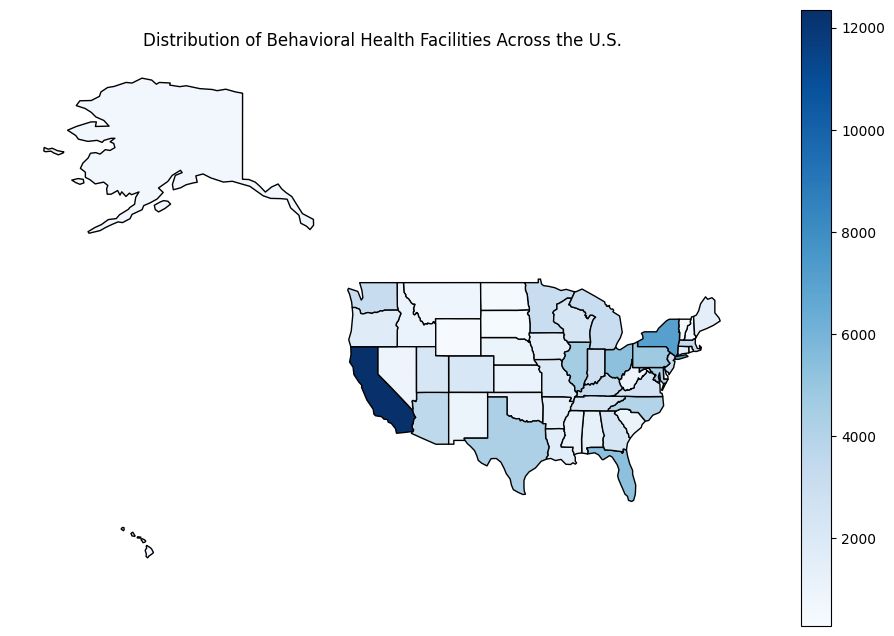

In [ ]:
# Distribution of behavioral health facilities across the U.S.
us_states = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/ne_110m_admin_1_states_provinces.shp")
us_states = us_states[us_states['admin'] == 'United States of America']

state_counts = df['state'].value_counts().reset_index()
state_counts.columns = ['state', 'count']

merged = us_states.merge(state_counts, left_on='postal', right_on='state', how='left')
merged.plot(
    column = 'count',
    cmap = 'Blues',
    legend = True,
    edgecolor = 'black',
    figsize= (12,8)
)

plt.title('Distribution of Behavioral Health Facilities Across the U.S.')
plt.axis('off')
plt.show()

This map shows the distribution of behavior health facilities across the U.S. States with darker shades of blue have a greater number of these facilities, while the states with lighter shades of blue have a lower number of behavior health facilities. This map may also suggest population density may influence access, raising concerns about disparities in healthcare systems in less populated areas.

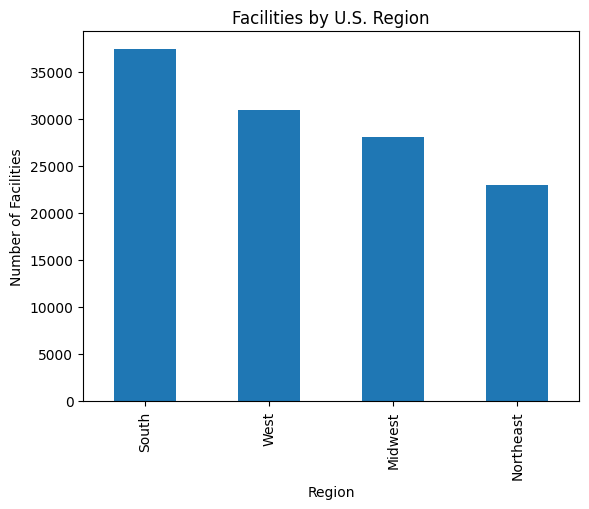

In [ ]:
# Number of Facilities vs. Region
# assign states to corresponding regions
south = ['AL','AR','DE','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','TX','VA','WV']
west = ['AK','AZ','CA','CO','HI','ID','MT','NV','NM','OR','UT','WA','WY']
midwest = ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']
northeast = ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']

region_map = {}

for state in south:
    region_map[state] = 'South'
for state in west:
    region_map[state] = 'West'
for state in midwest:
    region_map[state] = 'Midwest'
for state in northeast:
    region_map[state] = 'Northeast'

df['region'] = df['state'].map(region_map)

region_counts = df['region'].value_counts()

region_counts.plot(kind='bar')
plt.title('Facilities by U.S. Region')
plt.xlabel('Region')
plt.ylabel('Number of Facilities')
plt.show()

This bar chart compares the relationship between region and number of facilities, roughly revealing how many facilities each region has. According to the graph, the South and West regions have the greatest number of health facilities

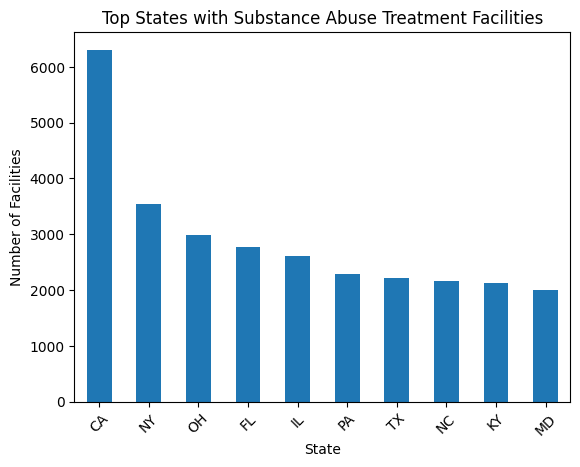

In [ ]:
# Top 10 States with Substance Abuse Treatment Facilities
substances_states = df[df['substance_treatment'] == 1]['state'].value_counts().head(10)

substances_states.plot(kind = 'bar')
plt.title('Top States with Substance Abuse Treatment Facilities')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.xticks(rotation = 45)
plt.show()

This bar chart highlights the top 10 U.S. states with the greatest number of facilities. According to the chart, California, New York, and Ohio have the most facilities of all states.

#### **b. Services**

In [ ]:
# mapping keys to values (FOCUS)
df['focus_mapping'] = df['primary_treatment_focus'].map({
    1: 'Substance Use Services',
    2: 'Mental Health Services',
    3: 'Both'
})

service_by_focus = df.groupby('focus_mapping')[services].mean().astype(float)

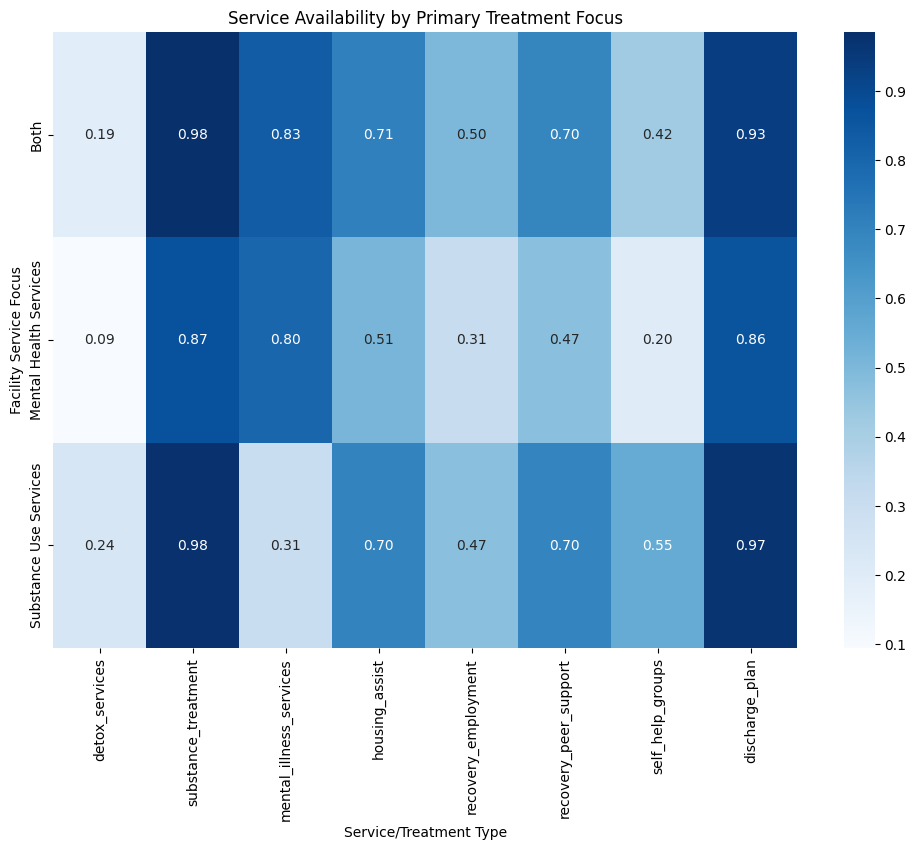

In [ ]:
# clustered heatmap comparing facility type to services offered
plt.figure(figsize=(12, 8))
sns.heatmap(service_by_focus,
            annot = True,
            cmap = 'Blues',
            fmt = ".2f")

plt.title('Service Availability by Primary Treatment Focus')
plt.xlabel('Service/Treatment Type')
plt.ylabel('Facility Service Focus')
plt.show()

This heatmap compares the availability of different treatments and services based on whether the facility focuses on substance use services, mental health services, or both. Facilities that focus on substance use have a higher availability in substance abuse treatment, and recovery help such as discharge plans, housing assistance, and peer support groups. Facilities focused on mental health services are more likely to offer both substance abuse treatment and mental illness treatment along with discharge plans.

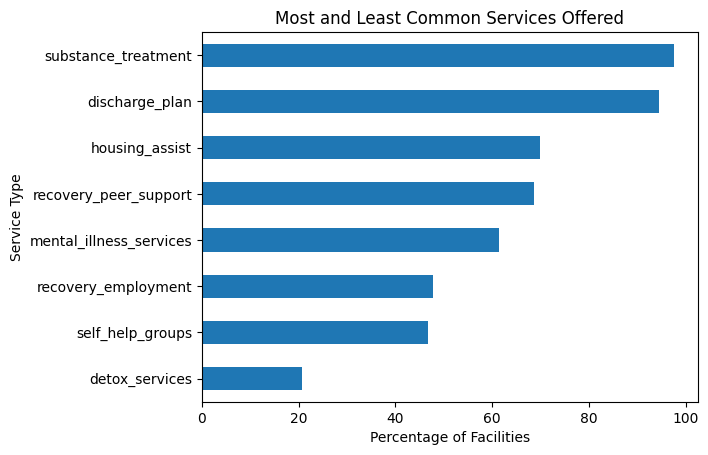

In [ ]:
# Most and Least Commonly Offered Services
services = [
    'detox_services', 'substance_treatment', 'mental_illness_services',
    'housing_assist', 'recovery_employment',
    'recovery_peer_support', 'self_help_groups', 'discharge_plan'
]

proportions = df[services].mean().sort_values(ascending = True) * 100

proportions.plot(kind='barh')
plt.title('Most and Least Common Services Offered')
plt.xlabel('Percentage of Facilities')
plt.ylabel('Service Type')
plt.show()

This bar graph compares the different types of services (y-axis) offered by behavior health facilities across the U.S. (x-axis). The most commonly offered services include substance treatment, discharge plan, and housing assitance. While, the least commonly offered services include recovery employment, self-help groups, and detox services.

#### **c. Demographics**

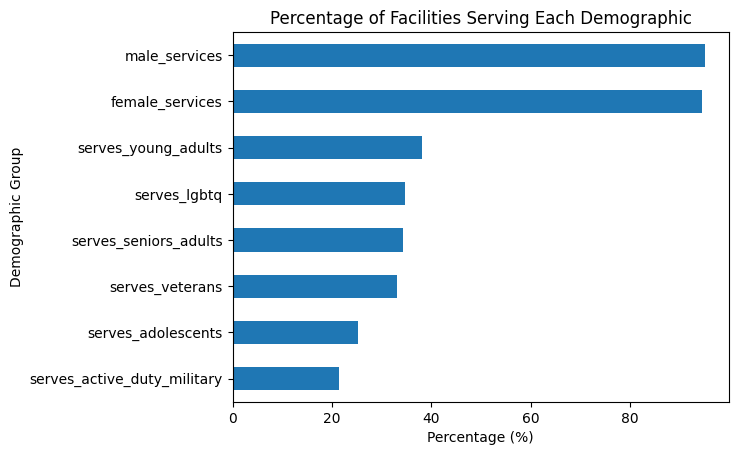

In [ ]:
# Demographics vs. Number of Facilities
demographics = [
    'serves_adolescents', 'serves_young_adults',
    'serves_seniors_adults', 'serves_lgbtq',
    'serves_veterans', 'serves_active_duty_military',
    'female_services', 'male_services'
]

demographic_percent = df[demographics].mean().sort_values() * 100

demographic_percent.plot(kind='barh')
plt.title('Percentage of Facilities Serving Each Demographic')
plt.xlabel('Percentage (%)')
plt.ylabel('Demographic Group')
plt.show()

This horizontal bar chart illustrates the proportion of behavioral health facilities serving various demographic groups. By displaying percentages for each group, the visualization highlights differences in service availability, helping identify which populations are more widely supported and which may face challenges in accessing care.

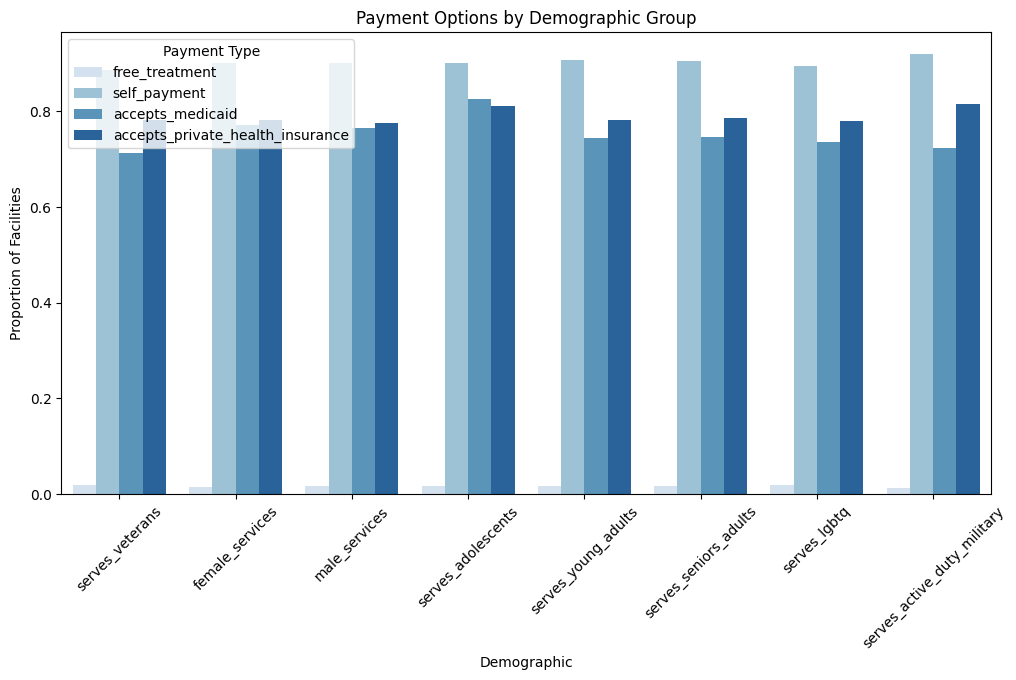

In [ ]:
demographics = ['serves_veterans', 'female_services', 'male_services',
                'serves_adolescents',  'serves_young_adults',
                'serves_seniors_adults', 'serves_lgbtq',
                'serves_active_duty_military']

payments = ['free_treatment', 'self_payment', 'accepts_medicaid',
            'accepts_private_health_insurance']

rows = []

# Calculate proportions directly
for d in demographics:
    subset = df[df[d] == 1]
    for p in payments:
        rows.append({
            'Demographic': d,
            'Payment Type': p,
            'Proportion': subset[p].mean()
        })

plot_data = pd.DataFrame(rows)

# Plot barchart
plt.figure(figsize = (12,6))

sns.barplot(
    data = plot_data,
    x = 'Demographic',
    y = 'Proportion',
    hue = 'Payment Type',
    palette = 'Blues'
)

plt.xticks(rotation = 45)
plt.title("Payment Options by Demographic Group")
plt.ylabel("Proportion of Facilities")
plt.show()



Description

#### **d. Finance**

In [ ]:
# dictionary mapping keys to values
# map 0 to No and 1 to Yes
adol_map = {0: 'No',
           1: 'Yes'}

In [ ]:
df['serves_adolescents'] = df['serves_adolescents'].map(adol_map)

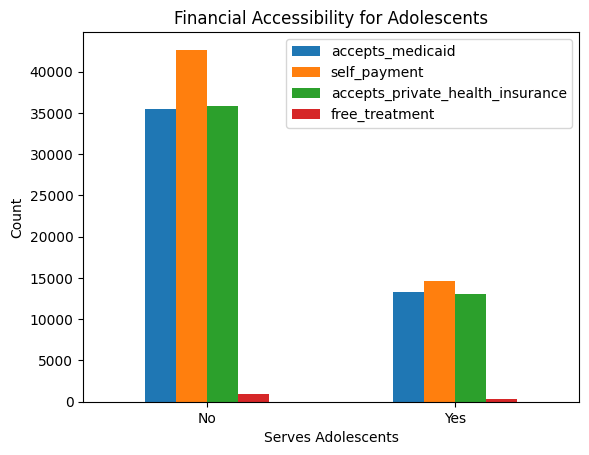

In [ ]:
financial = ['accepts_medicaid', 'self_payment', 'accepts_private_health_insurance', 'free_treatment']

demo_financial = df.groupby('serves_adolescents')[financial].sum()

demo_financial.plot(kind = 'bar')
plt.title('Financial Accessibility for Adolescents')
plt.xlabel('Serves Adolescents')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.show()

This bar chart illustrates the financial accessibility of behavioral health facilities based on whether they serve adolescents. It compares the total number of facilities that accept Medicaid, private health insurance, or offer free treatment. According to the graph, self payment, medicaid, and private health insurance are the most commonly accepted in behavioral health facilities that don't serve adolescents.

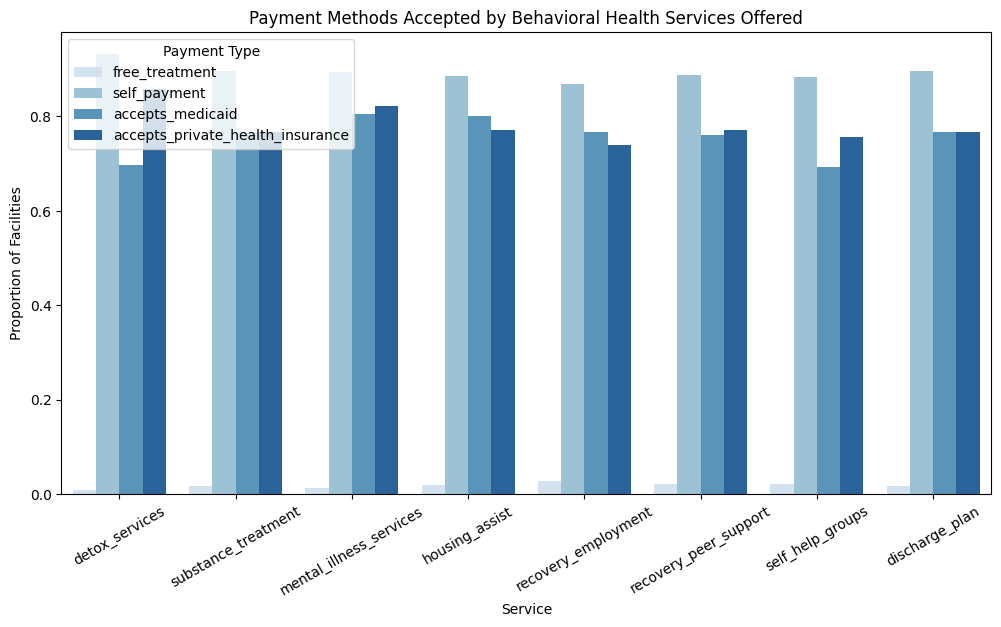

In [ ]:
services = [
    'detox_services', 'substance_treatment', 'mental_illness_services',
    'housing_assist', 'recovery_employment',
    'recovery_peer_support', 'self_help_groups', 'discharge_plan'
]

payments = ['free_treatment', 'self_payment', 'accepts_medicaid',
            'accepts_private_health_insurance'
]

rows = []
#chat GPT
#Loop through services
for s in services:
  subset = df[df[s] == 1]
  for p in payments:
    rows.append({
      'Service': s,
      'Payment Type': p,
      'Proportion': subset[p].mean()
  })

plot_data = pd.DataFrame(rows)

plt.figure(figsize =(12,6))

sns.barplot(
    data = plot_data,
    x = 'Service',
    y = 'Proportion',
    hue = 'Payment Type',
    palette = 'Blues'
)

plt.xticks(rotation = 30)
plt.title("Payment Methods Accepted by Behavioral Health Services Offered")
plt.ylabel("Proportion of Facilities")
plt.show()


This graph shows the proportion of services that accept certain payment types. According to the graph the most commonly accepted form of payment  is self payment, meaning out of pocket, followed by private health insurance. The least common accepted form of payment is free treatment.

## **6. Summarize Findings**

**Overview**

All data in this document is public information that may be reproduced and copied without permission from source, SAMHSA. Data collected from The Substance Abuse and Mental Health Services Administration (SAMHSA) does not disciminate or exclude based on race, color, national origin, age, disability, religion, or sex. This analysis explored the distribution of behavioral health facilities across the U.S., they variety of services they provide, and how availability varies by geography and population groups.

**1. Are behavior health facilities evenly distributed across the U.S. relative to population size?**

The distribution of health facilites in the U.S. varies across the states, with higher concentrations in states with higher populations. States such as California, Texas, Flordia, and New York have a higher number of facilities, while more rural states tend to have fewer resources. The number of facilities does not always scale proportionally with population as some densley populated areas are underserved relative to demand, while other less populated regions have limited facilities available. This data is also reflected when sorting facilities by regions South, West, Midwest, and Northeast. The chart shows the South having the highest concentration of facilities likely due to the vast number in California. These findings suggest that population size plays a role in access but is not a deciding factor as regional discrepencies persist.

**2. What types of services are most and least commonly offered?**

The core treatment service offered across facilities is substance abuse treatment. Along with treatment a majority of the facilities offer recovery services including discharge plans,housing assistance, and peer support services. Looking at this data set substance abuse treatments are much more commonly provided compared to mental illness treaments, which may be seen as a problem since many mental health illnesses lead to substance abuse or vise versa. While many facilites offer immidiate treatment needs, fewer provide long term recovery support to assist patients after they leave the program.

**3. Is there a relationship between facility type and services offered?**

The analysis reveals a clear relationship between primary treamtent focus and the services offered. Substance use facilities are significantly more likely to provide substance abuse treatment, aswell as recovery support for patients through discharge plans, housing assistance, and peer support. Mental health facilites focus more on substance abuse and mental health services, and discharge plans. Mental health facilities vary with their focus on both substances and mental health where as substance use facilities don't focus on mental illness services. Mental health facilities don't focus on post patient recovery as much as substance use facilites.

**4. What disparities exist in access to behavioral health services?**

There are several disparities present when focusing on access to behavioral health services. Geographical disparities are present across states, with many regions offering fewer services compared to more densely populated areas. Fewer facilities focus on minority populations such as LGBTQ individuals, veterans, active duty military, and adolesence. These gaps in care suggest certain populations may face barriers to accessing specialized care.

**5. How does financial accessibility affect different age groups and demographics?**

Financial accessibility varies and may disproportionaly affect various demographics. While many facilities accept private health insurance and medicaid, fewer offer free treatment options. This limitation greatly impacts vulnerable populations, including younger indiviuals, lower-income groups, and those without insurance.

**6. How do payment options vary across different behavioral health services?**

Overall, the analysis of national substance use and mental health services in the U.S. are not equally distributed, either geographically or by population size. While core treatment services are widely accessible, there is a clear gap in support and recovery treatment services. Disparties in access exist for specific demographic groups and regions, and financial inequalities continue to limit accessibility for vulnerable populations.

**Limitations:**

- Since this data represents facilities and not individuals recieving care, the analysis does not cover patient outcomes, quality of care, or actual patient experiences
- All data is self reported which introduces possible reporting bias into data set
- Many variables contained missing or incomplete values which may affect the accuracy of the analysis


**Next Steps:**

- These findings highlight the need for a more balanced and equally available health care system, by expanding supportive services, improving geographical distributions, and increasing access to affordable treatment for all.
- Future research could be conducted by incorporating population adjusted metrics to better assess service availability, as well as analysising the effectiveness of a variety of healthcare services. Future projects could also incorporate patient data and outcomes to reflect how different facilities and services effect patient health.